In [1]:
import os, sys
import pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 1) Load PCA scores
scores_df = pd.read_csv("results/pca/pca_scores.csv", index_col=0)
print("PCA scores shape:", scores_df.shape)

# 2) Load metadata
meta = pd.read_csv("data/processed/metadata_samples.csv")
print("Metadata shape:", meta.shape)
print("Metadata columns:", meta.columns.tolist())


PCA scores shape: (60, 21)
Metadata shape: (60, 7)
Metadata columns: ['sample_id', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor']


In [67]:
from pathlib import Path
import os

# Set repo root relative to current working directory
REPO_ROOT = Path.cwd().parents[0]  # goes up from notebooks/ → repo root
os.chdir(REPO_ROOT)

print("Working directory set to:", Path.cwd())

Working directory set to: /Users/acastano/Desktop


In [2]:
# Try to identify the column that matches sample IDs
# (you might need to adjust this name once we see the columns)
possible_id_cols = ["sample_id", "Sample", "sample", "library_id", "Run"]
for col in possible_id_cols:
    if col in meta.columns:
        print("Checking match for:", col)
        print("How many overlap?:", meta[col].isin(scores_df.index).sum())


Checking match for: sample_id
How many overlap?: 60


In [3]:
meta = meta.set_index("sample_id")
meta = meta.loc[scores_df.index]  # align order to PCA scores

meta.head()


,GSM,title,cell_type,hours,guide,donor
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3


In [4]:
import pandas as pd

meta = pd.read_csv("data/processed/metadata_samples.csv")
print("Meta columns:", meta.columns.tolist())
meta.head()


Meta columns: ['sample_id', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor']


,sample_id,GSM,title,cell_type,hours,guide,donor
0,CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1
1,CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1
2,CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2
3,CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2
4,CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3


In [5]:
print(meta["hours"].value_counts())
print(meta["guide"].value_counts())


hours
0      12
24     12
72     12
168    12
240    12
Name: count, dtype: int64
guide
SafeHarbor    30
RHOG          30
Name: count, dtype: int64


In [6]:
pca_with_meta = scores_df.join(meta.set_index("sample_id"))


In [7]:
pca_with_meta = scores_df.join(meta.set_index("sample_id"))


In [8]:
# Align metadata by sample_id
meta = meta.set_index("sample_id")

# Reorder metadata to match PCA score order (important!)
meta = meta.loc[scores_df.index]

# Combine (optional but nice)
pca_with_meta = scores_df.join(meta)

pca_with_meta.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC18,PC19,PC20,quadrant_PC1_PC2,GSM,title,cell_type,hours,guide,donor
CART0077_RNAseq_NgsRun1_001,-37.723277,-31.705538,-12.123623,-2.744340,-15.144212,-9.991624,-3.412902,7.700148,-5.771141,2.742833,...,0.301871,1.009762,3.626065,Q3,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1
CART0077_RNAseq_NgsRun1_002,-39.836363,-31.833348,-10.900892,-3.312477,-15.591511,-8.813367,-3.750231,9.619637,-6.636606,4.066675,...,-0.198813,-1.158450,0.854416,Q3,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1
CART0077_RNAseq_NgsRun1_003,-31.637766,-29.746144,-17.107666,-0.723304,-11.271251,-9.780588,12.959361,-2.573610,-3.644878,-2.881499,...,3.038072,2.845002,0.094177,Q3,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2
CART0077_RNAseq_NgsRun1_004,-40.140399,-31.899786,-12.068343,-3.726443,-14.294023,-6.180032,12.564387,3.884865,-7.805759,2.527802,...,2.716472,-4.457068,-3.141289,Q3,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2
CART0077_RNAseq_NgsRun1_005,-40.540445,-32.856847,-10.222355,-8.728795,-22.326515,12.585187,-1.935315,-1.552674,-10.996653,2.630127,...,-1.186169,2.094334,-0.515822,Q3,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3


In [9]:
print("Timepoints:", sorted(pca_with_meta['hours'].unique()))
print("\nPerturbations:", pca_with_meta['guide'].unique())
print("\nCounts per perturbation:")
print(pca_with_meta['guide'].value_counts())


Timepoints: [np.int64(0), np.int64(24), np.int64(72), np.int64(168), np.int64(240)]

Perturbations: ['SafeHarbor' 'RHOG']

Counts per perturbation:
guide
SafeHarbor    30
RHOG          30
Name: count, dtype: int64


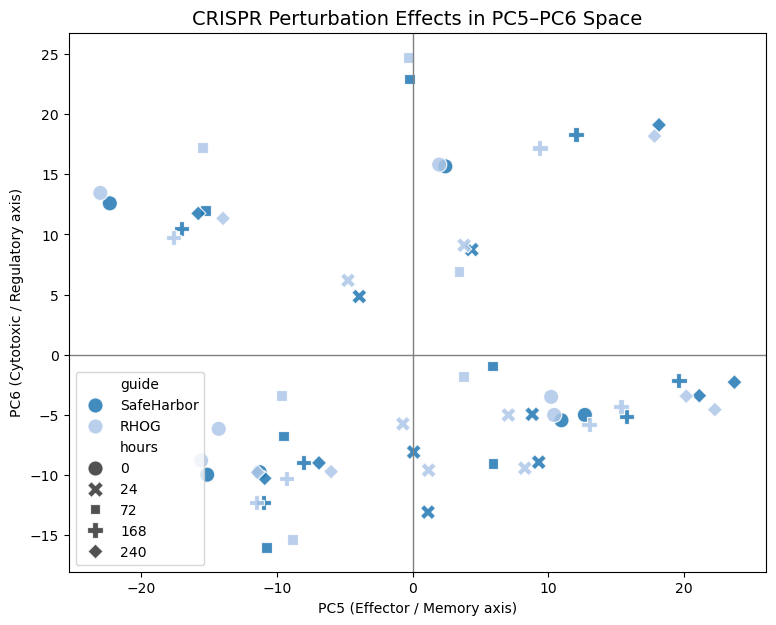

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_with_meta,
    x="PC5", y="PC6",
    hue="guide",        # perturbation
    style="hours",      # time point
    s=120,
    alpha=0.85,
    palette="tab20"
)

plt.title("CRISPR Perturbation Effects in PC5–PC6 Space", fontsize=14)
plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)
plt.xlabel("PC5 (Effector / Memory axis)")
plt.ylabel("PC6 (Cytotoxic / Regulatory axis)")
plt.show()


In [11]:
print("Guides:", sorted(pca_with_meta["guide"].unique()))
print("Timepoints:", sorted(pca_with_meta["hours"].unique()))


Guides: ['RHOG', 'SafeHarbor']
Timepoints: [np.int64(0), np.int64(24), np.int64(72), np.int64(168), np.int64(240)]


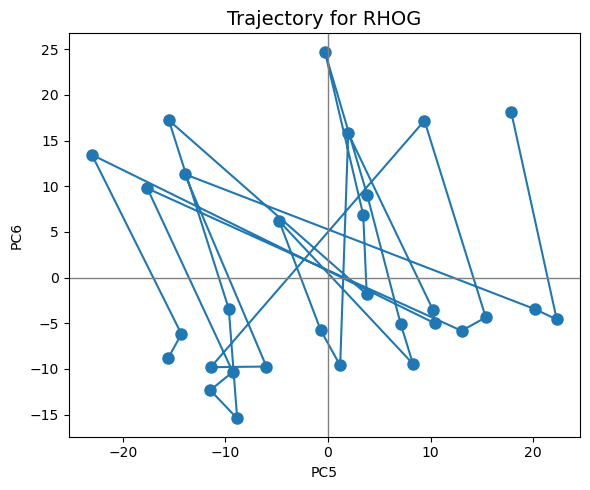

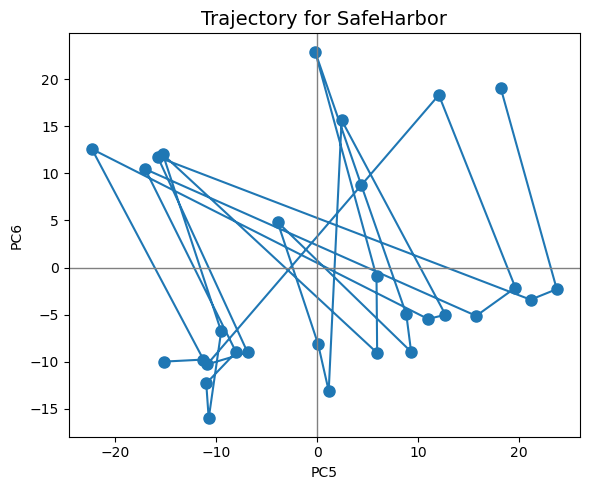

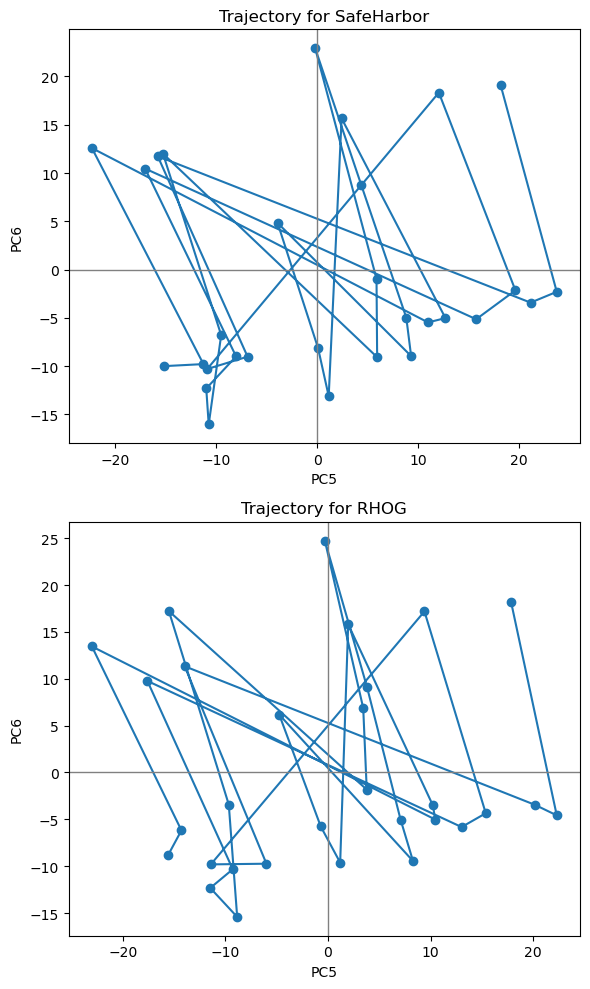

In [12]:
import matplotlib.pyplot as plt

guides = sorted(pca_with_meta["guide"].unique())

for g in guides:
    df = pca_with_meta[pca_with_meta["guide"] == g].sort_values("hours")

    plt.figure(figsize=(6, 5))
    plt.plot(df["PC5"], df["PC6"], "-o", markersize=8)
    plt.title(f"Trajectory for {g}", fontsize=14)
    plt.xlabel("PC5")
    plt.ylabel("PC6")
    plt.axhline(0, color="gray", lw=1)
    plt.axvline(0, color="gray", lw=1)
    plt.tight_layout()
    plt.show()
    # --- FIX TRAJECTORY ORDERING ---
guides = pca_with_meta["guide"].unique()

fig, axes = plt.subplots(len(guides), 1, figsize=(6, 10))

for ax, g in zip(axes, guides):
    df_g = pca_with_meta[pca_with_meta["guide"] == g].copy()
    df_g = df_g.sort_values("hours")   # ← THIS FIXES THE SPAGHETTI

    ax.plot(df_g["PC5"], df_g["PC6"], marker="o")
    ax.set_title(f"Trajectory for {g}")
    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1)
    ax.set_xlabel("PC5")
    ax.set_ylabel("PC6")

plt.tight_layout()
plt.show()



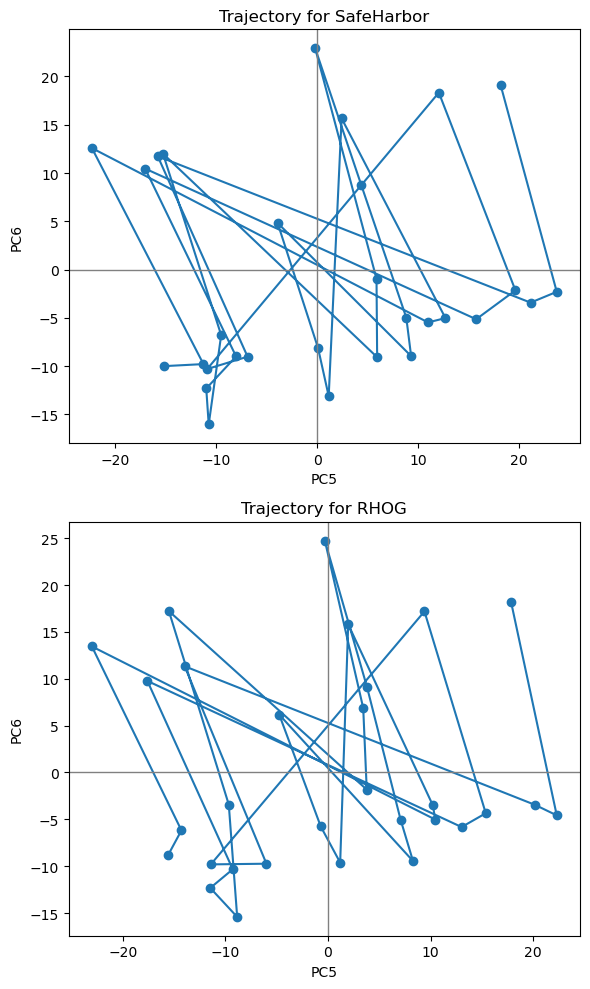

In [13]:
# --- FIX TRAJECTORY ORDERING ---
guides = pca_with_meta["guide"].unique()

fig, axes = plt.subplots(len(guides), 1, figsize=(6, 10))

for ax, g in zip(axes, guides):
    df_g = pca_with_meta[pca_with_meta["guide"] == g].copy()
    df_g = df_g.sort_values("hours")   # ← THIS FIXES THE SPAGHETTI

    ax.plot(df_g["PC5"], df_g["PC6"], marker="o")
    ax.set_title(f"Trajectory for {g}")
    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1)
    ax.set_xlabel("PC5")
    ax.set_ylabel("PC6")

plt.tight_layout()
plt.show()


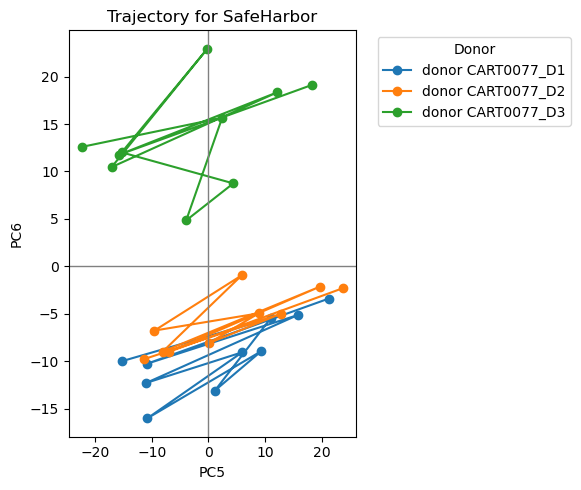

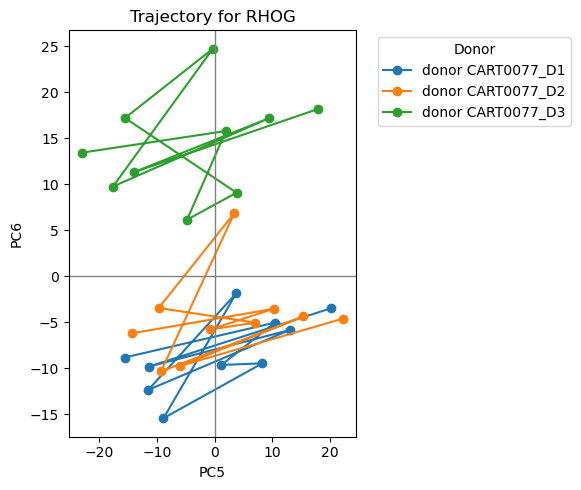

In [14]:
import matplotlib.pyplot as plt

guides = ["SafeHarbor", "RHOG"]  # or list(pca_with_meta["guide"].unique())

for g in guides:
    df_g = pca_with_meta[pca_with_meta["guide"] == g].copy()

    plt.figure(figsize=(6, 5))
    for donor, df_d in df_g.groupby("donor"):
        df_d = df_d.sort_values("hours")  # order time within donor

        plt.plot(
            df_d["PC5"],
            df_d["PC6"],
            "-o",
            label=f"donor {donor}"
        )

    plt.title(f"Trajectory for {g}")
    plt.xlabel("PC5")
    plt.ylabel("PC6")
    plt.axhline(0, color="gray", lw=1)
    plt.axvline(0, color="gray", lw=1)
    plt.legend(title="Donor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [15]:
pca_with_meta[pca_with_meta["hours"] == 0].groupby("donor")[["PC5","PC6"]].mean()


,PC5,PC6
donor,,
CART0077_D1,-2.324456,-7.322978
CART0077_D2,-0.655511,-6.123810
CART0077_D3,-10.240103,14.376457


In [16]:
pca_with_meta.groupby(["donor","hours"]).size()


donor        hours
CART0077_D1  0        4
             24       4
             72       4
             168      4
             240      4
CART0077_D2  0        4
             24       4
             72       4
             168      4
             240      4
CART0077_D3  0        4
             24       4
             72       4
             168      4
             240      4
dtype: int64

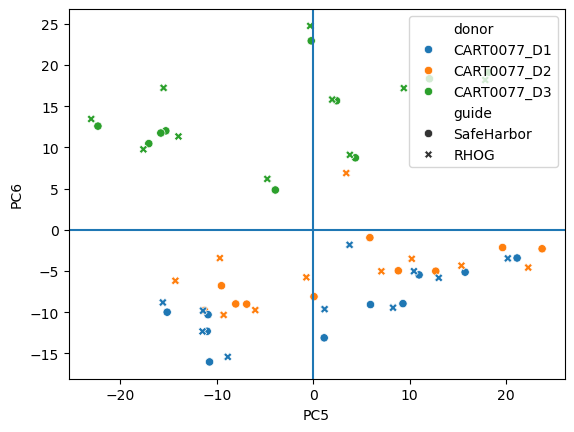

In [17]:
sns.scatterplot(
    data=pca_with_meta, x="PC5", y="PC6", hue="donor", style="guide"
)
plt.axhline(0); plt.axvline(0)
plt.show()


In [18]:
ΔPC5 = PC5(time X) – PC5(time 0)
ΔPC6 = PC6(time X) – PC6(time 0)


SyntaxError: invalid character '–' (U+2013) (1023354708.py, line 1)

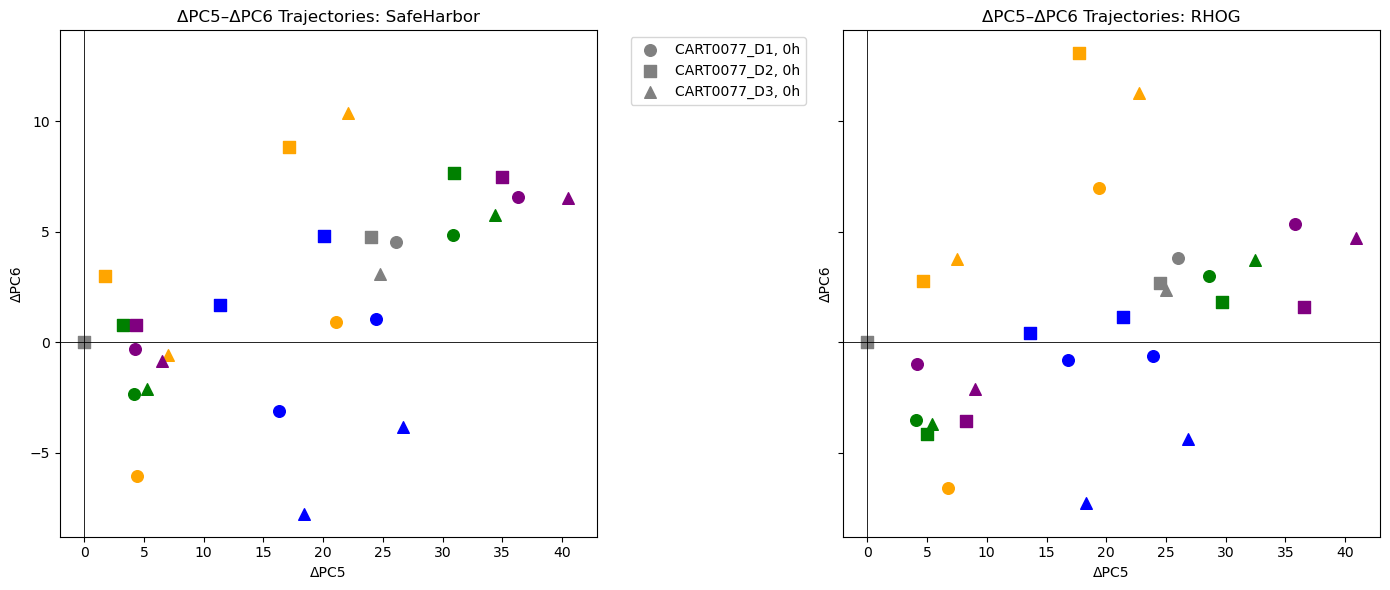

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Copy dataframe
df = pca_with_meta.copy()

# Compute ΔPC5 and ΔPC6 relative to each donor's 0h baseline
df["PC5_delta"] = df["PC5"] - df.groupby(["guide", "donor"])["PC5"].transform(lambda x: x[df["hours"]==0].iloc[0])
df["PC6_delta"] = df["PC6"] - df.groupby(["guide", "donor"])["PC6"].transform(lambda x: x[df["hours"]==0].iloc[0])

# Define colors per time
time_palette = {
    0: "gray",
    24: "blue",
    72: "orange",
    168: "green",
    240: "purple"
}

# Define marker per donor
donor_markers = {
    "CART0077_D1": "o",
    "CART0077_D2": "s",
    "CART0077_D3": "^"
}

guides = ["SafeHarbor", "RHOG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df[df["guide"] == guide]
    
    for donor in sub["donor"].unique():
        sub_d = sub[sub["donor"] == donor]
        for h in sorted(sub_d["hours"].unique()):
            sub_h = sub_d[sub_d["hours"] == h]
            ax.scatter(
                sub_h["PC5_delta"], 
                sub_h["PC6_delta"],
                color=time_palette[h],
                marker=donor_markers[donor],
                s=70,
                label=f"{donor}, {h}h" if h == 0 else None  # only label once
            )
    
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_title(f"ΔPC5–ΔPC6 Trajectories: {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

# Deduplicate legend entries
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axes[0].legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



In [20]:
import pandas as pd

df = pca_with_meta.copy()

# 1️⃣ Compute baseline PC5 / PC6 at 0h for each (guide, donor)
baseline = (
    df[df["hours"] == 0]
    .groupby(["guide", "donor"])[["PC5", "PC6"]]
    .mean()
    .rename(columns={"PC5": "PC5_0", "PC6": "PC6_0"})
)

# 2️⃣ Join baseline back onto all rows
df = df.join(baseline, on=["guide", "donor"])

# 3️⃣ Compute deltas
df["dPC5"] = df["PC5"] - df["PC5_0"]
df["dPC6"] = df["PC6"] - df["PC6_0"]


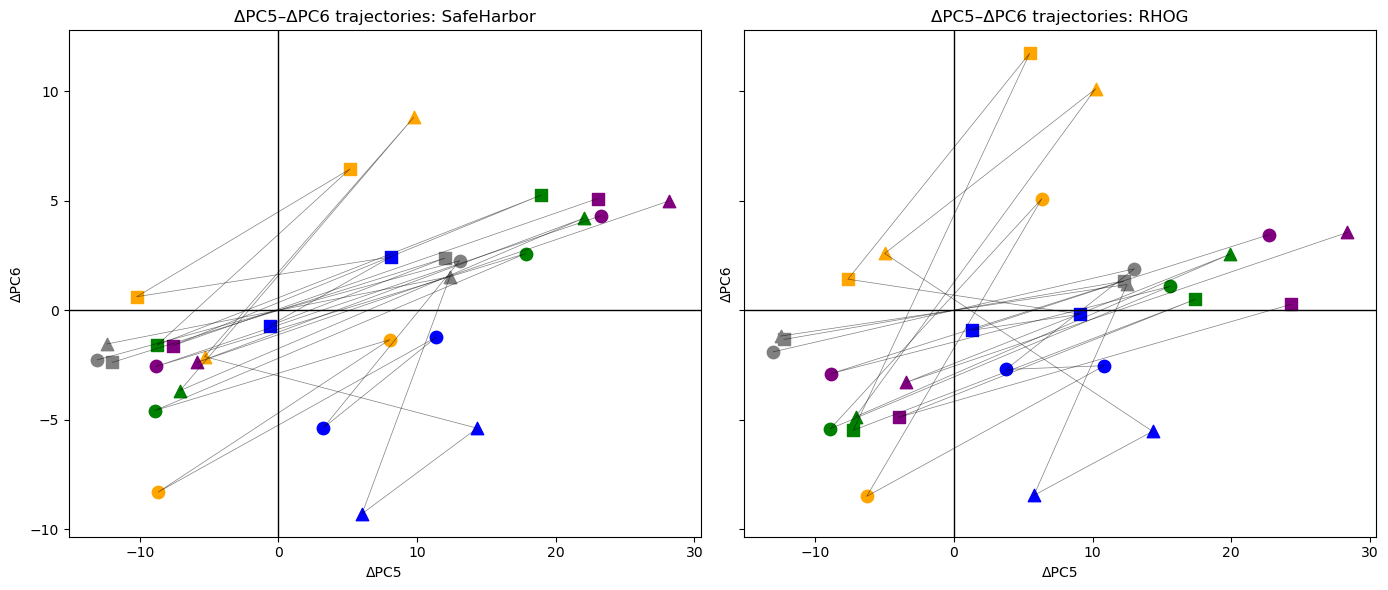

In [21]:
time_palette = {0:"gray", 24:"blue", 72:"orange", 168:"green", 240:"purple"}
donor_markers = {"CART0077_D1":"o", "CART0077_D2":"s", "CART0077_D3":"^"}

guides = ["SafeHarbor", "RHOG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df[df["guide"] == guide]

    for donor, marker in donor_markers.items():
        sd = sub[sub["donor"] == donor]
        if sd.empty:
            continue

        # scatter each time point
        for h, color in time_palette.items():
            sdh = sd[sd["hours"] == h]
            ax.scatter(
                sdh["dPC5"],
                sdh["dPC6"],
                color=color,
                marker=marker,
                s=80,
            )

        # connect timepoints in order for that donor
        sd_sorted = sd.sort_values("hours")
        ax.plot(sd_sorted["dPC5"], sd_sorted["dPC6"],
                color="black", linewidth=0.5, alpha=0.5)

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"ΔPC5–ΔPC6 trajectories: {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

plt.tight_layout()
plt.show()


In [22]:
df = pca_with_meta.copy()

# Baseline per (guide, donor) at 0h
baseline = (
    df[df["hours"] == 0]
    .groupby(["guide", "donor"])[["PC5", "PC6"]]
    .mean()
    .rename(columns={"PC5": "PC5_0", "PC6": "PC6_0"})
)

df = df.join(baseline, on=["guide", "donor"])
df["dPC5"] = df["PC5"] - df["PC5_0"]
df["dPC6"] = df["PC6"] - df["PC6_0"]

# 👉 collapse replicates: mean ΔPC per (guide, donor, hours)
df_mean = (
    df.groupby(["guide", "donor", "hours"])[["dPC5", "dPC6"]]
    .mean()
    .reset_index()
)


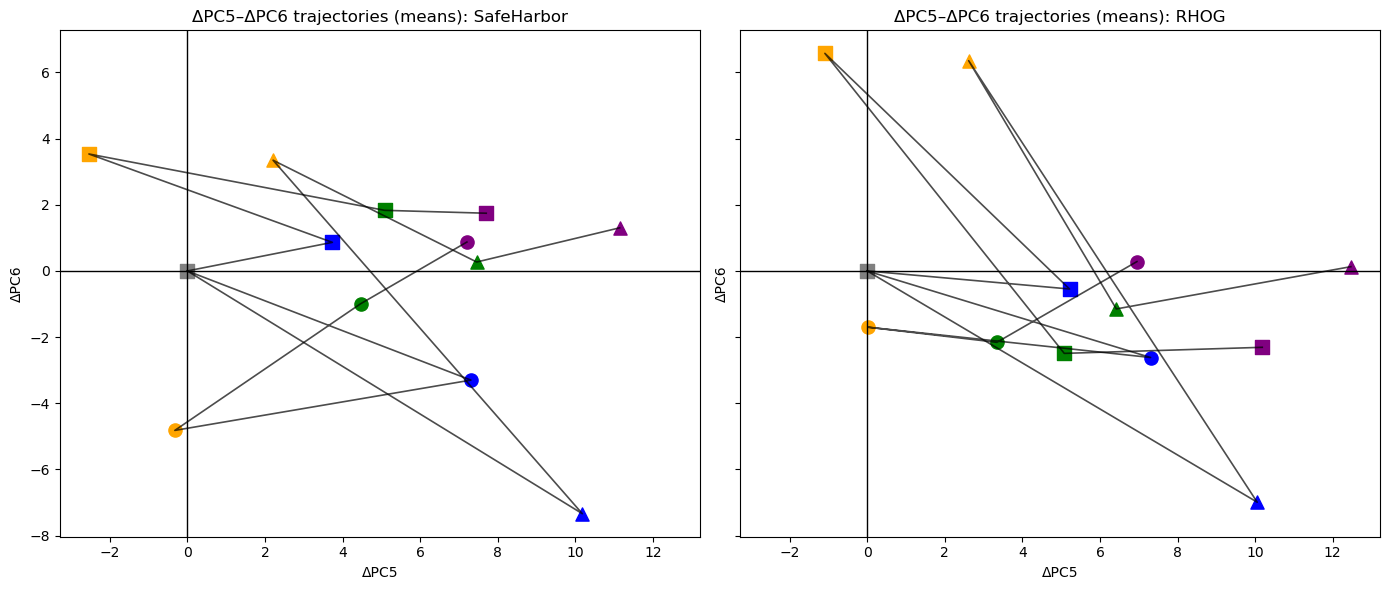

In [23]:
import matplotlib.pyplot as plt

time_palette = {0:"gray", 24:"blue", 72:"orange", 168:"green", 240:"purple"}
donor_markers = {"CART0077_D1":"o", "CART0077_D2":"s", "CART0077_D3":"^"}
guides = ["SafeHarbor", "RHOG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df_mean[df_mean["guide"] == guide]

    for donor, marker in donor_markers.items():
        sd = sub[sub["donor"] == donor]
        if sd.empty:
            continue

        # plot each timepoint
        for h in sorted(sd["hours"].unique()):
            sdh = sd[sd["hours"] == h]
            ax.scatter(
                sdh["dPC5"],
                sdh["dPC6"],
                color=time_palette[h],
                marker=marker,
                s=90,
            )

        # connect mean points over time
        sd_sorted = sd.sort_values("hours")
        ax.plot(
            sd_sorted["dPC5"],
            sd_sorted["dPC6"],
            color="black",
            linewidth=1.2,
            alpha=0.7,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"ΔPC5–ΔPC6 trajectories (means): {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

plt.tight_layout()
plt.show()


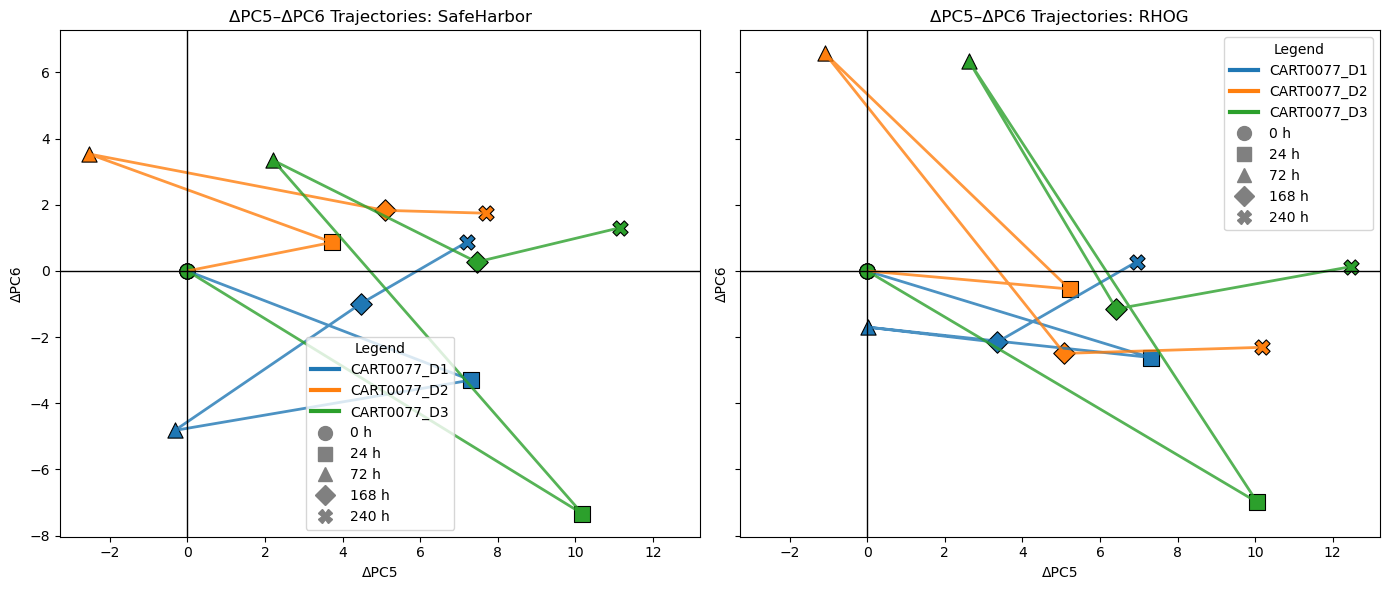

In [24]:
import matplotlib.pyplot as plt

# --- Color by donor ---
donor_colors = {
    "CART0077_D1": "#1f77b4",   # blue
    "CART0077_D2": "#ff7f0e",   # orange
    "CART0077_D3": "#2ca02c",   # green
}

# --- Marker by timepoint ---
time_markers = {
    0: "o",      # circle
    24: "s",     # square
    72: "^",     # triangle
    168: "D",    # diamond
    240: "X",    # X marker
}

guides = ["SafeHarbor", "RHOG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df_mean[df_mean["guide"] == guide]

    for donor in donor_colors.keys():
        sd = sub[sub["donor"] == donor]
        if sd.empty:
            continue

        # Sort by time progression
        sd = sd.sort_values("hours")

        # Draw donor trajectory line
        ax.plot(
            sd["dPC5"], sd["dPC6"],
            color=donor_colors[donor],
            linewidth=2,
            alpha=0.8,
            label=donor
        )

        # Draw each time point with a unique marker
        for _, row in sd.iterrows():
            ax.scatter(
                row["dPC5"], row["dPC6"],
                color=donor_colors[donor],
                marker=time_markers[row["hours"]],
                s=120,
                edgecolor="black",
                linewidth=0.8
            )

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"ΔPC5–ΔPC6 Trajectories: {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

    # Combined legend: donor colors & time markers
    # Donor legend
    donor_handles = [
        plt.Line2D([0], [0], color=c, lw=3, label=d)
        for d, c in donor_colors.items()
    ]
    # Time legend
    time_handles = [
        plt.Line2D([0], [0], color="gray", marker=m, linestyle="", markersize=10, label=f"{t} h")
        for t, m in time_markers.items()
    ]

    ax.legend(handles=donor_handles + time_handles, title="Legend", loc="best")

plt.tight_layout()
plt.show()


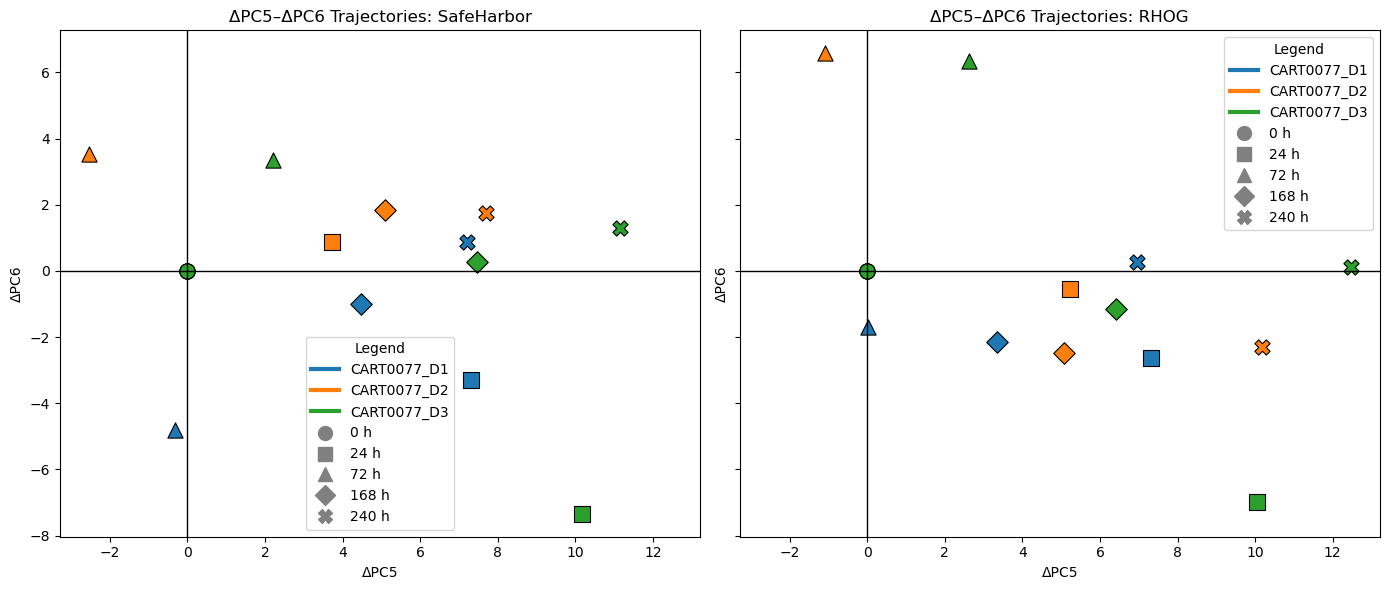

In [25]:
import matplotlib.pyplot as plt

# --- Color by donor ---
donor_colors = {
    "CART0077_D1": "#1f77b4",   # blue
    "CART0077_D2": "#ff7f0e",   # orange
    "CART0077_D3": "#2ca02c",   # green
}

# --- Marker by timepoint ---
time_markers = {
    0: "o",      # circle
    24: "s",     # square
    72: "^",     # triangle
    168: "D",    # diamond
    240: "X",    # X marker
}

guides = ["SafeHarbor", "RHOG"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df_mean[df_mean["guide"] == guide]

    for donor in donor_colors.keys():
        sd = sub[sub["donor"] == donor]
        if sd.empty:
            continue

        # Sort by time progression
        sd = sd.sort_values("hours")

        

        # Draw each time point with a unique marker
        for _, row in sd.iterrows():
            ax.scatter(
                row["dPC5"], row["dPC6"],
                color=donor_colors[donor],
                marker=time_markers[row["hours"]],
                s=120,
                edgecolor="black",
                linewidth=0.8
            )

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"ΔPC5–ΔPC6 Trajectories: {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

    # Combined legend: donor colors & time markers
    # Donor legend
    donor_handles = [
        plt.Line2D([0], [0], color=c, lw=3, label=d)
        for d, c in donor_colors.items()
    ]
    # Time legend
    time_handles = [
        plt.Line2D([0], [0], color="gray", marker=m, linestyle="", markersize=10, label=f"{t} h")
        for t, m in time_markers.items()
    ]

    ax.legend(handles=donor_handles + time_handles, title="Legend", loc="best")

plt.tight_layout()
plt.show()



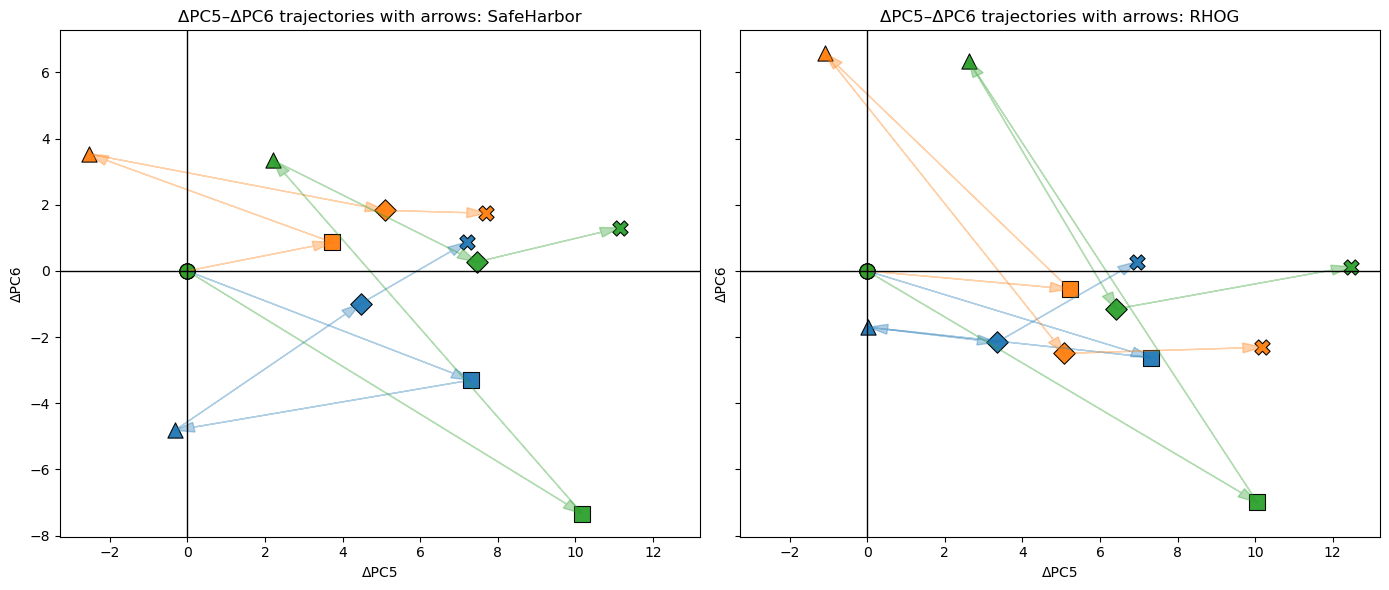

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, guide in zip(axes, guides):
    sub = df_mean[df_mean["guide"] == guide]

    # Scatter points
    for _, row in sub.iterrows():
        donor = row["donor"]
        h = row["hours"]
        ax.scatter(
            row["dPC5"], row["dPC6"],
            color=donor_colors[donor],
            marker=time_markers[h],
            s=120,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95
        )

    # Arrows between timepoints per donor
    for donor in sub["donor"].unique():
        sd = sub[sub["donor"] == donor].sort_values("hours")
        for (x0, y0), (x1, y1) in zip(sd[["dPC5","dPC6"]].values[:-1],
                                      sd[["dPC5","dPC6"]].values[1:]):
            ax.arrow(
                x0, y0,
                x1 - x0, y1 - y0,
                length_includes_head=True,
                head_width=0.3,
                head_length=0.5,
                color=donor_colors[donor],
                alpha=0.35,
                linewidth=1
            )

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"ΔPC5–ΔPC6 trajectories with arrows: {guide}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

plt.tight_layout()
plt.show()


In [27]:
import numpy as np

end_time = 240

endpoints = (
    df_mean[df_mean["hours"] == end_time]
    .assign(
        displacement=lambda d: np.sqrt(d["dPC5"]**2 + d["dPC6"]**2)
    )
    .loc[:, ["guide", "donor", "dPC5", "dPC6", "displacement"]]
)

print(endpoints)


         guide        donor       dPC5      dPC6  displacement
4         RHOG  CART0077_D1   6.952093  0.282648      6.957837
9         RHOG  CART0077_D2  10.182135 -2.308007     10.440439
14        RHOG  CART0077_D3  12.466112  0.129194     12.466781
19  SafeHarbor  CART0077_D1   7.204709  0.873295      7.257442
24  SafeHarbor  CART0077_D2   7.703009  1.744501      7.898077
29  SafeHarbor  CART0077_D3  11.141598  1.303449     11.217584


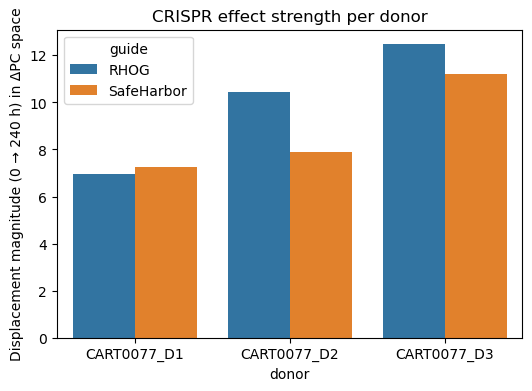

In [28]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=endpoints,
    x="donor", y="displacement", hue="guide"
)
plt.ylabel(f"Displacement magnitude (0 → {end_time} h) in ΔPC space")
plt.title("CRISPR effect strength per donor")
plt.show()


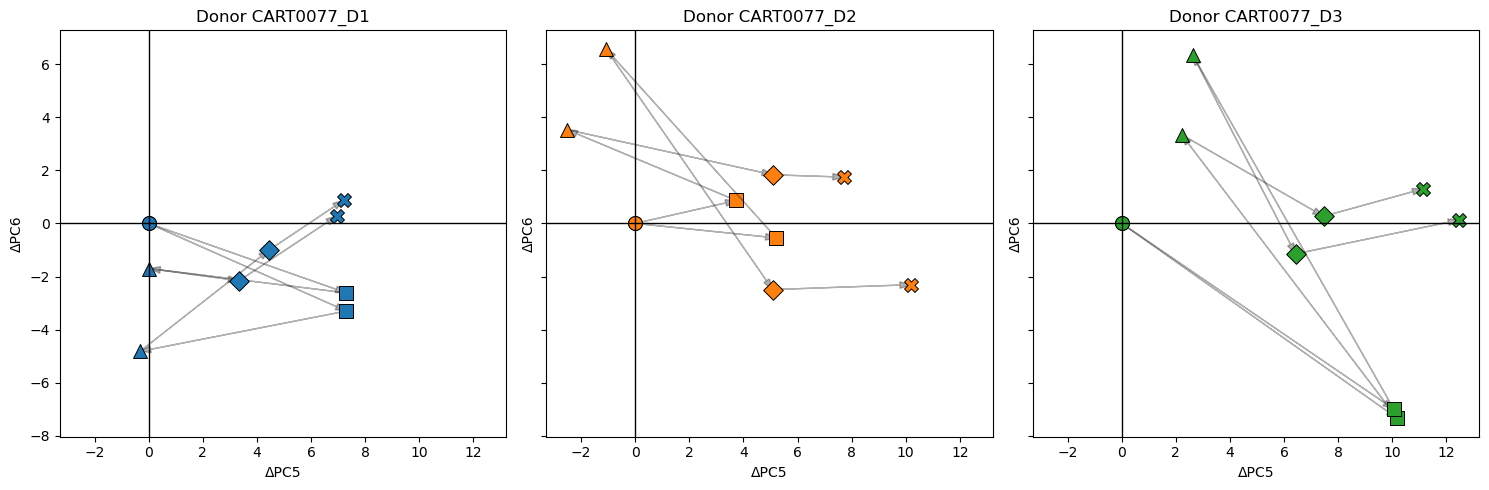

In [29]:
donors = sorted(df_mean["donor"].unique())

fig, axes = plt.subplots(1, len(donors), figsize=(5*len(donors), 5), sharex=True, sharey=True)

for ax, donor in zip(axes, donors):
    sub = df_mean[df_mean["donor"] == donor]

    for guide, style in zip(guides, ["-", "--"]):
        sg = sub[sub["guide"] == guide].sort_values("hours")

        # trajectory arrows
        for (x0, y0), (x1, y1) in zip(sg[["dPC5","dPC6"]].values[:-1],
                                      sg[["dPC5","dPC6"]].values[1:]):
            ax.arrow(
                x0, y0,
                x1 - x0, y1 - y0,
                length_includes_head=True,
                head_width=0.25,
                head_length=0.4,
                color="black",
                alpha=0.3
            )

        # points
        for _, row in sg.iterrows():
            ax.scatter(
                row["dPC5"], row["dPC6"],
                color=donor_colors[donor],
                marker=time_markers[row["hours"]],
                s=100,
                edgecolor="black",
                linewidth=0.7,
                label=f"{guide} {row['hours']}h"
            )

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Donor {donor}")
    ax.set_xlabel("ΔPC5")
    ax.set_ylabel("ΔPC6")

plt.tight_layout()
plt.show()


In [30]:
import pandas as pd

# 1. Load PCA loadings (ENSEMBL-indexed)
loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

# 2. Load ENSG → symbol map
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")

print("Mapping columns:", ensg_map.columns)
print(ensg_map.head())



Mapping columns: Index(['ensembl', 'symbol'], dtype='object')
           ensembl   symbol
0  ENSG00000210049    MT-TF
1  ENSG00000211459  MT-RNR1
2  ENSG00000210077    MT-TV
3  ENSG00000210082  MT-RNR2
4  ENSG00000209082   MT-TL1


In [31]:
# Keep only rows with both ensembl and symbol, drop duplicate ENSGs
ensg_map = (
    ensg_map
    .dropna(subset=["ensembl", "symbol"])
    .drop_duplicates("ensembl")
)

# Build mapping: ENSG → gene_symbol
mapping = ensg_map.set_index("ensembl")["symbol"]
print("Mapping size:", mapping.shape)


Mapping size: (46920,)


In [32]:
import pandas as pd

loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

print("Index example:", loadings_df.index[:5].tolist())
print("Columns:", loadings_df.columns.tolist())

key_genes = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B",
             "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4", "NKG7"]

genes_present = [g for g in key_genes if g in loadings_df.index]
print("Genes found in index:", genes_present)


Index example: ['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267', 'ENSG00000243485', 'ENSG00000284332']
Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'quadrant_PC1_PC2']
Genes found in index: []


In [33]:
# 1. Load the ENSEMBL → symbol mapping
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")

print(ensg_map.head())
print(ensg_map.columns)


           ensembl   symbol
0  ENSG00000210049    MT-TF
1  ENSG00000211459  MT-RNR1
2  ENSG00000210077    MT-TV
3  ENSG00000210082  MT-RNR2
4  ENSG00000209082   MT-TL1
Index(['ensembl', 'symbol'], dtype='object')


In [34]:
# Keep only rows with both ensembl and symbol, drop duplicate ENSGs
ensg_map = (
    ensg_map
    .dropna(subset=["ensembl", "symbol"])
    .drop_duplicates("ensembl")
)

# Build mapping: ENSG → gene_symbol
mapping = ensg_map.set_index("ensembl")["symbol"]
print("Mapping size:", mapping.shape)


Mapping size: (46920,)


In [35]:
# loadings_df index should be ENSG IDs
print("Example loadings index:", loadings_df.index[:5].tolist())

loadings_df = loadings_df.copy()
loadings_df["gene_symbol"] = loadings_df.index.map(mapping)

# Drop rows without symbol & use gene_symbol as index
loadings_symbol = (
    loadings_df
    .dropna(subset=["gene_symbol"])
    .set_index("gene_symbol")
)

print("shape with symbols:", loadings_symbol.shape)
print("example index:", loadings_symbol.index[:10].tolist())



Example loadings index: ['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267', 'ENSG00000243485', 'ENSG00000284332']
shape with symbols: (41269, 21)
example index: ['DDX11L1', 'WASH7P', 'MIR6859-1', 'MIR1302-2HG', 'MIR1302-2', 'FAM138A', 'OR4G4P', 'OR4G11P', 'OR4F5', 'CICP27']


Genes present: ['PRF1', 'GZMB', 'IFNG', 'TNF', 'CD8A', 'CD8B', 'CCR7', 'TCF7', 'IL7R', 'SMAD2', 'CCR4', 'NKG7']


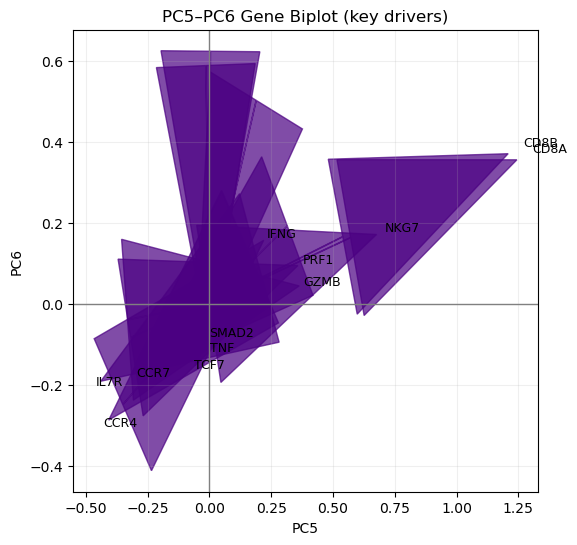

In [36]:
import matplotlib.pyplot as plt

key_genes = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B",
             "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4", "NKG7"]

# Filter to genes that actually exist in the loadings
genes_present = [g for g in key_genes if g in loadings_symbol.index]
print("Genes present:", genes_present)

L = loadings_symbol.loc[genes_present, ["PC5", "PC6"]]

scale = 10  # adjust if arrows too big/small

plt.figure(figsize=(6, 6))
plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)

for g in genes_present:
    x = L.loc[g, "PC5"] * scale
    y = L.loc[g, "PC6"] * scale
    plt.arrow(0, 0, x, y,
              length_includes_head=True,
              head_width=0.4,
              head_length=0.7,
              color = "#4B0082",  # indigo
              alpha=0.7)
              
    plt.text(x * 1.05, y * 1.05, g, fontsize=9)


plt.xlabel("PC5")
plt.ylabel("PC6")
plt.title("PC5–PC6 Gene Biplot (key drivers)")
plt.grid(True, alpha=0.2)
plt.show()


In [37]:
# Get top 20 strongest contributors toward the upper-left
vec = loadings_symbol[["PC5", "PC6"]]

# Define vector direction for upper-left
target = (-1, 1)

# Cosine similarity: how aligned each gene is with upper-left
vec_norm = vec.div((vec["PC5"]**2 + vec["PC6"]**2)**0.5, axis=0)
similarity = vec_norm["PC5"]*target[0] + vec_norm["PC6"]*target[1]

top_UL = similarity.sort_values(ascending=False).head(20)
top_UL


gene_symbol
ARHGEF26      1.414214
AZU1          1.414214
LINC01477     1.414214
SEC22C        1.414213
RXYLT1-AS1    1.414213
SRP14-DT      1.414213
EEF1DP5       1.414213
MST1L         1.414213
PBX3          1.414213
LINC00305     1.414212
LINC02318     1.414212
B3GALT4       1.414212
TRIM34        1.414211
MOCOS         1.414211
IL1RN         1.414211
LINC01413     1.414210
THOC7         1.414210
RIC3          1.414210
DPY30         1.414210
FSTL3         1.414209
dtype: float64

In [38]:
import pandas as pd

# 1. Load PCA loadings (ENSEMBL-indexed)
loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

# 2. Load ENSG → symbol map
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")

print("Mapping columns:", ensg_map.columns)
print(ensg_map.head())


Mapping columns: Index(['ensembl', 'symbol'], dtype='object')
           ensembl   symbol
0  ENSG00000210049    MT-TF
1  ENSG00000211459  MT-RNR1
2  ENSG00000210077    MT-TV
3  ENSG00000210082  MT-RNR2
4  ENSG00000209082   MT-TL1


In [39]:
#0. Load + align everything
import numpy as np
import pandas as pd

# 1) Expression (genes x samples, index = gene_symbol, columns = sample_id)
expr = pd.read_csv("expr_logcpm_gene_symbols.csv", index_col=0)

# 2) Metadata
meta = pd.read_csv("metadata_samples.csv")  # has sample_id, donor, hours, guide

# 3) PCA scores (samples x PCs, index = sample_id)
pca_scores = pd.read_csv("pca_scores.csv", index_col=0)

# Align everything to the same sample order
meta = meta.set_index("sample_id")
common_samples = expr.columns.intersection(meta.index).intersection(pca_scores.index)

expr = expr[common_samples]
meta = meta.loc[common_samples]
pca_scores = pca_scores.loc[common_samples]

# Attach PC5/PC6 to metadata
meta[["PC5", "PC6"]] = pca_scores[["PC5", "PC6"]]


FileNotFoundError: [Errno 2] No such file or directory: 'expr_logcpm_gene_symbols.csv'

In [40]:
effector_genes = [
    "PRF1", "GZMB", "NKG7", "CD8A", "CD8B", "IFNG", "TNF"
]

reg_genes = [
    "IL1RN", "FSTL3", "ARHGEF26", "SEC22C", "TRIM34",
    "AZU1", "SEC22C", "MST1L", "PBX3", "THOC7", "RIC3"
    # add more from your PC6⁺ list as needed
]


In [41]:
# Z-score genes and average (classic module scoring) Filter to genes present
eff_genes_present = [g for g in effector_genes if g in expr.index]
reg_genes_present = [g for g in reg_genes if g in expr.index]

print("Effector genes present:", eff_genes_present)
print("Reg genes present:", reg_genes_present)

# Z-score per gene (row-wise)
expr_z = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1) + 1e-6, axis=0)

# Module scores (mean z-score)
effector_score = expr_z.loc[eff_genes_present].mean(axis=0)
reg_score      = expr_z.loc[reg_genes_present].mean(axis=0)

meta["effector_score"] = effector_score
meta["reg_score"]      = reg_score


NameError: name 'expr' is not defined

In [42]:
#Compute Δmodule trajectories and vector speeds
#Sort by donor/guide/hours and compute deltas
meta_traj = meta.copy()
meta_traj["hours"] = meta_traj["hours"].astype(float)

meta_traj = meta_traj.sort_values(["donor", "guide", "hours"])

def add_module_deltas(df):
    df = df.sort_values("hours").copy()
    df["d_eff"] = df["effector_score"].diff()
    df["d_reg"] = df["reg_score"].diff()
    df["dt"]    = df["hours"].diff()

    # vector length in module space (per step)
    df["step_distance"] = np.sqrt(df["d_eff"]**2 + df["d_reg"]**2)

    # speed per hour (if you want time-normalized)
    df["speed_per_hour"] = df["step_distance"] / df["dt"].replace(0, np.nan)

    # direction angle (reg vs eff), optional but nice:
    df["angle_rad"] = np.arctan2(df["d_reg"], df["d_eff"])

    return df

meta_traj = meta_traj.groupby(["donor", "guide"], group_keys=False).apply(add_module_deltas)


KeyError: 'effector_score'

In [ ]:
#Classify PCA quadrants (PC5/PC6)
def quadrant_label(row):
    if row["PC5"] >= 0 and row["PC6"] >= 0:
        return "Q1: Eff+ / Reg+"
    elif row["PC5"] < 0 and row["PC6"] >= 0:
        return "Q2: Eff- / Reg+"
    elif row["PC5"] < 0 and row["PC6"] < 0:
        return "Q3: Eff- / Reg-"
    else:
        return "Q4: Eff+ / Reg-"

meta_traj["PC_quadrant"] = meta_traj.apply(quadrant_label, axis=1)


ValueError: Could not interpret value `effector_score` for `y`. An entry with this name does not appear in `data`.

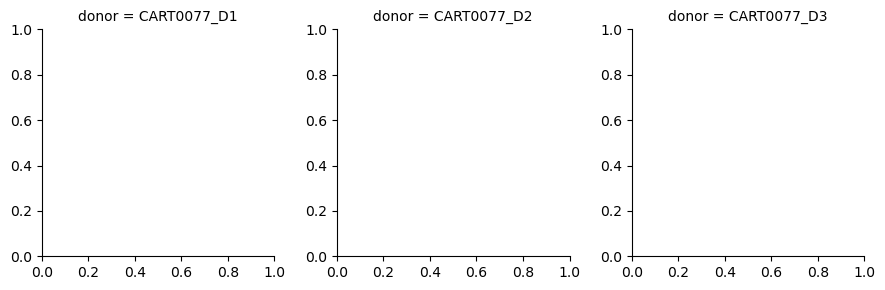

In [43]:
#Effector vs regulatory over time (per donor, colored by guide)
import seaborn as sns
import matplotlib.pyplot as plt

# Reset index so sample_id is a column if you want it in plots
meta_plot = meta_traj.reset_index()

# 1) Effector score over time
g = sns.FacetGrid(meta_plot, col="donor", hue="guide", sharey=False, col_wrap=3)
g.map_dataframe(sns.lineplot, x="hours", y="effector_score", marker="o")
g.add_legend()
g.set_axis_labels("Hours", "Effector module score")
plt.suptitle("Effector module over time by donor/guide", y=1.02)
plt.tight_layout()

# 2) Regulatory score over time
g = sns.FacetGrid(meta_plot, col="donor", hue="guide", sharey=False, col_wrap=3)
g.map_dataframe(sns.lineplot, x="hours", y="reg_score", marker="o")
g.add_legend()
g.set_axis_labels("Hours", "Regulatory module score")
plt.suptitle("Regulatory module over time by donor/guide", y=1.02)
plt.tight_layout()


KeyError: 'effector_score'

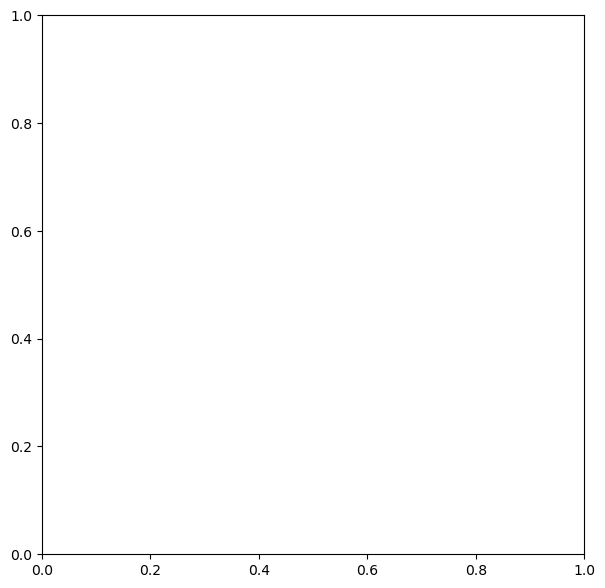

In [44]:
#Module trajectory plots (effector vs regulatory space)
fig, ax = plt.subplots(figsize=(7, 7))

for (donor, guide), df in meta_traj.groupby(["donor", "guide"]):
    df = df.sort_values("hours")
    ax.plot(df["effector_score"], df["reg_score"], marker="o", linestyle="-",
            label=f"D{donor} | {guide}", alpha=0.8)

    # Add arrows for steps
    ax.quiver(
        df["effector_score"][:-1], df["reg_score"][:-1],
        df["d_eff"].iloc[1:], df["d_reg"].iloc[1:],
        angles="xy", scale_units="xy", scale=1, alpha=0.6
    )

ax.set_xlabel("Effector module score")
ax.set_ylabel("Regulatory module score")
ax.axvline(0, linestyle="--", alpha=0.4)
ax.axhline(0, linestyle="--", alpha=0.4)

ax.set_title("Trajectories in effector–regulatory module space")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


In [45]:
#Quadrant transitions over time
plt.figure(figsize=(10, 4))
sns.stripplot(
    data=meta_plot,
    x="hours", y="PC_quadrant",
    hue="guide", dodge=True, jitter=0.2
)
plt.xlabel("Hours")
plt.ylabel("PC5/PC6 quadrant")
plt.title("Quadrant transitions over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


ValueError: Could not interpret value `PC_quadrant` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

In [46]:
#Save the enriched metadata for downstream work
meta_traj.to_csv("metadata_with_modules_and_trajectories.csv")


In [47]:
# New chat beginning, Load expression using your project structure
import os, glob
import numpy as np
import pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)

# You already have these:
scores_df = pd.read_csv("results/pca/pca_scores.csv", index_col=0)
meta      = pd.read_csv("data/processed/metadata_samples.csv").set_index("sample_id")
meta      = meta.loc[scores_df.index]
pca_with_meta = scores_df.join(meta)

print("pca_with_meta shape:", pca_with_meta.shape)
print("pca_with_meta columns:", pca_with_meta.columns.tolist())


pca_with_meta shape: (60, 27)
pca_with_meta columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'quadrant_PC1_PC2', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor']


In [48]:
import pandas as pd

expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
expr_logcpm.head(), expr_logcpm.shape


(                 CART0077_RNAseq_NgsRun1_001  CART0077_RNAseq_NgsRun1_002  \
 gene                                                                        
 ENSG00000223972                     0.000000                     0.000000   
 ENSG00000227232                     1.976637                     2.143149   
 ENSG00000278267                     0.233659                     0.084208   
 ENSG00000243485                     0.000000                     0.000000   
 ENSG00000284332                     0.000000                     0.000000   
 
                  CART0077_RNAseq_NgsRun1_003  CART0077_RNAseq_NgsRun1_004  \
 gene                                                                        
 ENSG00000223972                     0.000000                     0.027546   
 ENSG00000227232                     1.518306                     1.814642   
 ENSG00000278267                     0.108840                     0.246303   
 ENSG00000243485                     0.000000                 

In [49]:
os.getcwd()
os.listdir("data/processed")


['expr_logcpm_symbol.parquet',
 'ensg_to_symbol.csv',
 'metadata_samples.csv',
 'expr_logcpm.parquet',
 '.ipynb_checkpoints']

In [50]:
import pandas as pd

# Expression matrix (genes × samples)
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
print("expr_logcpm:", expr_logcpm.shape)

# Sample metadata
meta = pd.read_csv("data/processed/metadata_samples.csv")
print("meta:", meta.shape)
print(meta.columns)

# PCA outputs
scores_df   = pd.read_csv("results/pca/pca_scores.csv", index_col=0)
loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)
explained_df = pd.read_csv("results/pca/pca_explained_variance.csv", index_col=0)

print("scores_df:", scores_df.shape)
print("loadings_df:", loadings_df.shape)


expr_logcpm: (60675, 60)
meta: (60, 7)
Index(['sample_id', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor'], dtype='object')
scores_df: (60, 21)
loadings_df: (60675, 21)


In [51]:
# Make sure sample_id matches the PCA index
meta = meta.set_index("sample_id")
meta = meta.loc[scores_df.index]

pca_with_meta = scores_df.join(meta)
pca_with_meta.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC18,PC19,PC20,quadrant_PC1_PC2,GSM,title,cell_type,hours,guide,donor
CART0077_RNAseq_NgsRun1_001,-37.723277,-31.705538,-12.123623,-2.744340,-15.144212,-9.991624,-3.412902,7.700148,-5.771141,2.742833,...,0.301871,1.009762,3.626065,Q3,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1
CART0077_RNAseq_NgsRun1_002,-39.836363,-31.833348,-10.900892,-3.312477,-15.591511,-8.813367,-3.750231,9.619637,-6.636606,4.066675,...,-0.198813,-1.158450,0.854416,Q3,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1
CART0077_RNAseq_NgsRun1_003,-31.637766,-29.746144,-17.107666,-0.723304,-11.271251,-9.780588,12.959361,-2.573610,-3.644878,-2.881499,...,3.038072,2.845002,0.094177,Q3,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2
CART0077_RNAseq_NgsRun1_004,-40.140399,-31.899786,-12.068343,-3.726443,-14.294023,-6.180032,12.564387,3.884865,-7.805759,2.527802,...,2.716472,-4.457068,-3.141289,Q3,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2
CART0077_RNAseq_NgsRun1_005,-40.540445,-32.856847,-10.222355,-8.728795,-22.326515,12.585187,-1.935315,-1.552674,-10.996653,2.630127,...,-1.186169,2.094334,-0.515822,Q3,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3


In [52]:
# ENSG → symbol map.# ENSG → symbol map. 
#Rebuild the gene-symbol loadings (for biplots & modules)
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")
print(ensg_map.columns)




Index(['ensembl', 'symbol'], dtype='object')


In [53]:
ensg_map = (
    ensg_map
    .dropna(subset=["ensembl", "symbol"])
    .drop_duplicates("ensembl")
)
mapping = ensg_map.set_index("ensembl")["symbol"]

loadings_df = loadings_df.copy()
loadings_df["gene_symbol"] = loadings_df.index.map(mapping)

loadings_symbol = (
    loadings_df
    .dropna(subset=["gene_symbol"])
    .set_index("gene_symbol")
)

print("loadings_symbol:", loadings_symbol.shape)


loadings_symbol: (41269, 21)


In [54]:
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)

# Expression matrix (genes × samples)
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
print("expr_logcpm:", expr_logcpm.shape)

# Sample metadata
meta = pd.read_csv("data/processed/metadata_samples.csv")
print("meta:", meta.shape)
print(meta.columns)

# PCA outputs
scores_df    = pd.read_csv("results/pca/pca_scores.csv", index_col=0)
loadings_df  = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)
explained_df = pd.read_csv("results/pca/pca_explained_variance.csv", index_col=0)

print("scores_df:", scores_df.shape)
print("loadings_df:", loadings_df.shape)


expr_logcpm: (60675, 60)
meta: (60, 7)
Index(['sample_id', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor'], dtype='object')
scores_df: (60, 21)
loadings_df: (60675, 21)


In [55]:
# Make sure metadata is indexed by sample_id
meta = meta.set_index("sample_id")

# expr_logcpm columns should be sample IDs
print("First 5 expr columns:", expr_logcpm.columns[:5])
print("First 5 PCA sample IDs:", scores_df.index[:5])

# Align to common samples
common_samples = scores_df.index.intersection(meta.index).intersection(expr_logcpm.columns)
print("Common samples:", len(common_samples))

scores_df    = scores_df.loc[common_samples]
meta         = meta.loc[common_samples]
expr         = expr_logcpm[common_samples]  # reorder columns

# Combine PCA scores + metadata
df = scores_df.join(meta)
print("Combined df shape:", df.shape)
print("Combined columns:", df.columns.tolist())


First 5 expr columns: Index(['CART0077_RNAseq_NgsRun1_001', 'CART0077_RNAseq_NgsRun1_002',
       'CART0077_RNAseq_NgsRun1_003', 'CART0077_RNAseq_NgsRun1_004',
       'CART0077_RNAseq_NgsRun1_005'],
      dtype='object')
First 5 PCA sample IDs: Index(['CART0077_RNAseq_NgsRun1_001', 'CART0077_RNAseq_NgsRun1_002',
       'CART0077_RNAseq_NgsRun1_003', 'CART0077_RNAseq_NgsRun1_004',
       'CART0077_RNAseq_NgsRun1_005'],
      dtype='object')
Common samples: 60
Combined df shape: (60, 27)
Combined columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'quadrant_PC1_PC2', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor']


In [56]:
print("Example gene IDs:", expr.index[:10].tolist())


Example gene IDs: ['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267', 'ENSG00000243485', 'ENSG00000284332', 'ENSG00000237613', 'ENSG00000268020', 'ENSG00000240361', 'ENSG00000186092', 'ENSG00000238009']


In [57]:
import pandas as pd

# 1. Load PCA loadings (ENSEMBL-indexed)
loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

# 2. Load ENSG → symbol map
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")

print("Mapping columns:", ensg_map.columns)
print(ensg_map.head())

Mapping columns: Index(['ensembl', 'symbol'], dtype='object')
           ensembl   symbol
0  ENSG00000210049    MT-TF
1  ENSG00000211459  MT-RNR1
2  ENSG00000210077    MT-TV
3  ENSG00000210082  MT-RNR2
4  ENSG00000209082   MT-TL1


In [58]:
effector_genes = [
    "PRF1", "GZMB", "NKG7", "CD8A", "CD8B", "IFNG", "TNF"
]

reg_genes = [
    "IL1RN", "FSTL3", "ARHGEF26", "SEC22C", "TRIM34",
    "AZU1", "MST1L", "PBX3", "THOC7", "RIC3"
    # add more PC6+ genes later if you want
]

eff_genes_present = [g for g in effector_genes if g in expr.index]
reg_genes_present = [g for g in reg_genes if g in expr.index]

print("Effector genes present:", eff_genes_present)
print("Regulatory genes present:", reg_genes_present)


Effector genes present: []
Regulatory genes present: []


In [59]:
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)

# Expression: genes × samples, ENSG index
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
print("expr_logcpm:", expr_logcpm.shape)
print("Example expr index:", expr_logcpm.index[:5].tolist())

# Metadata
meta = pd.read_csv("data/processed/metadata_samples.csv")
meta = meta.set_index("sample_id")
print("meta:", meta.shape)

# PCA
scores_df    = pd.read_csv("results/pca/pca_scores.csv", index_col=0)
loadings_df  = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)
explained_df = pd.read_csv("results/pca/pca_explained_variance.csv", index_col=0)

print("scores_df:", scores_df.shape)
print("loadings_df:", loadings_df.shape)


expr_logcpm: (60675, 60)
Example expr index: ['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267', 'ENSG00000243485', 'ENSG00000284332']
meta: (60, 6)
scores_df: (60, 21)
loadings_df: (60675, 21)


In [60]:
import pandas as pd

# 1. Load PCA loadings (ENSEMBL-indexed)
loadings_df = pd.read_csv("results/pca/pca_loadings.csv", index_col=0)

# 2. Load ENSG → symbol map
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")

print("Mapping columns:", ensg_map.columns)
print(ensg_map.head())

Mapping columns: Index(['ensembl', 'symbol'], dtype='object')
           ensembl   symbol
0  ENSG00000210049    MT-TF
1  ENSG00000211459  MT-RNR1
2  ENSG00000210077    MT-TV
3  ENSG00000210082  MT-RNR2
4  ENSG00000209082   MT-TL1


In [61]:
ensg_map = pd.read_csv("data/processed/ensg_to_symbol.csv")
print("Mapping columns:", ensg_map.columns.tolist())

# Try to infer ID and symbol columns
id_candidates = ["ensembl_id", "ensembl_gene_id", "gene_id", "ensembl"]
sym_candidates = ["gene_symbol", "symbol", "hgnc_symbol"]

id_col = next((c for c in id_candidates if c in ensg_map.columns), None)
sym_col = next((c for c in sym_candidates if c in ensg_map.columns), None)

print("Using id_col:", id_col)
print("Using sym_col:", sym_col)

if id_col is None or sym_col is None:
    raise ValueError("Could not infer id/symbol columns from ensg_to_symbol.csv; please check the header.")


Mapping columns: ['ensembl', 'symbol']
Using id_col: ensembl
Using sym_col: symbol


In [62]:
# Clean mapping: drop rows without symbol, deduplicate on ENSG
gene_map_clean = (
    ensg_map
    .dropna(subset=[sym_col])
    .drop_duplicates(subset=[id_col])
)

symbol_by_ensg = gene_map_clean.set_index(id_col)[sym_col]

# Map expression index
expr_symbol = expr_logcpm.copy()
expr_symbol["gene_symbol"] = expr_symbol.index.map(symbol_by_ensg)

print("Mapped genes with symbols:", expr_symbol["gene_symbol"].notna().sum(), "of", expr_symbol.shape[0])

# Drop rows where mapping failed, set new index to symbol, aggregate duplicates by mean
expr_symbol = (
    expr_symbol
    .dropna(subset=["gene_symbol"])
    .set_index("gene_symbol")
    .groupby(level=0).mean()
)

expr = expr_symbol
print("expr (symbol space):", expr.shape)
print("Example gene symbols:", expr.index[:10].tolist())


Mapped genes with symbols: 41269 of 60675
expr (symbol space): (41250, 60)
Example gene symbols: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1', 'A2ML1-AS2', 'A2MP1', 'A3GALT2']


In [63]:
# Align on sample IDs
common_samples = scores_df.index.intersection(meta.index).intersection(expr.columns)
print("Common samples:", len(common_samples))

scores_df = scores_df.loc[common_samples]
meta      = meta.loc[common_samples]
expr      = expr[common_samples]  # reorder columns

df = scores_df.join(meta)
df["hours"] = df["hours"].astype(float)

print("df shape:", df.shape)
print("df columns:", df.columns.tolist())


Common samples: 60
df shape: (60, 27)
df columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'quadrant_PC1_PC2', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor']


In [64]:
#Module scores (effector + regulatory)
effector_genes = [
    "PRF1", "GZMB", "NKG7", "CD8A", "CD8B", "IFNG", "TNF"
]

reg_genes = [
    "IL1RN", "FSTL3", "ARHGEF26", "SEC22C", "TRIM34",
    "AZU1", "MST1L", "PBX3", "THOC7", "RIC3"
]

eff_genes_present = [g for g in effector_genes if g in expr.index]
reg_genes_present = [g for g in reg_genes if g in expr.index]

print("Effector genes present:", eff_genes_present)
print("Regulatory genes present:", reg_genes_present)

# Z-score per gene
expr_z = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1) + 1e-6, axis=0)

effector_score = expr_z.loc[eff_genes_present].mean(axis=0)
reg_score      = expr_z.loc[reg_genes_present].mean(axis=0)

df["effector_score"] = effector_score
df["reg_score"]      = reg_score


Effector genes present: ['PRF1', 'GZMB', 'NKG7', 'CD8A', 'CD8B', 'IFNG', 'TNF']
Regulatory genes present: ['IL1RN', 'FSTL3', 'ARHGEF26', 'SEC22C', 'TRIM34', 'AZU1', 'MST1L', 'PBX3', 'THOC7', 'RIC3']


In [65]:
#Δmodule trajectories, speeds, and quadrants
df = df.sort_values(["donor", "guide", "hours"])

def add_module_deltas(gr):
    gr = gr.sort_values("hours").copy()
    gr["d_eff"] = gr["effector_score"].diff()
    gr["d_reg"] = gr["reg_score"].diff()
    gr["dt"]    = gr["hours"].diff()

    gr["step_distance"] = np.sqrt(gr["d_eff"]**2 + gr["d_reg"]**2)
    gr["speed_per_hour"] = gr["step_distance"] / gr["dt"].replace(0, np.nan)
    gr["angle_rad"] = np.arctan2(gr["d_reg"], gr["d_eff"])
    return gr

df_traj = df.groupby(["donor", "guide"], group_keys=False).apply(add_module_deltas)

def quadrant_label(row):
    if row["PC5"] >= 0 and row["PC6"] >= 0:
        return "Q1: Eff+ / Reg+"
    elif row["PC5"] < 0 and row["PC6"] >= 0:
        return "Q2: Eff- / Reg+"
    elif row["PC5"] < 0 and row["PC6"] < 0:
        return "Q3: Eff- / Reg-"
    else:
        return "Q4: Eff+ / Reg-"

df_traj["PC_quadrant"] = df_traj.apply(quadrant_label, axis=1)


/var/folders/qx/x9q1q3ns1hl9156prswwpk5m0000gn/T/ipykernel_7522/2434306436.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_traj = df.groupby(["donor", "guide"], group_keys=False).apply(add_module_deltas)


In [66]:
#Save enriched metadata
os.makedirs("results/modules", exist_ok=True)
out_path = "results/modules/metadata_with_modules_and_trajectories.csv"
df_traj.to_csv(out_path, index=True)

print("Saved enriched metadata to:", out_path)
print("Final shape:", df_traj.shape)
print("Columns:", df_traj.columns.tolist())


Saved enriched metadata to: results/modules/metadata_with_modules_and_trajectories.csv
Final shape: (60, 36)
Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'quadrant_PC1_PC2', 'GSM', 'title', 'cell_type', 'hours', 'guide', 'donor', 'effector_score', 'reg_score', 'd_eff', 'd_reg', 'dt', 'step_distance', 'speed_per_hour', 'angle_rad', 'PC_quadrant']
